# Decorator

In [ ]:
def decorator():
    def inner_func(a:int, b:int):
        return a + b

In [16]:
def generator_fun():
    for i in range(5):
        yield f"yield{i}"

# for i in generator_fun():
#     print(i)

# gen = generator_fun()
# next(gen)  # -> yield0
# next(gen)  # -> yield1
# next(gen)
# next(gen)

# print(generator_fun())
# gen = generator_fun()
# print(gen)

# next(generator_fun())
# next(generator_fun()) 
# output is only only yield0

a = generator_fun()  # held in memory
b = generator_fun()  # held in memory
c = generator_fun()  # held in memory

print(a)  # 0x0000018F3236D240
print(b)  # 0x0000018F3236D260  ← different!
print(c)  # 0x0000018F3236D280  ← different!


<generator object generator_fun at 0x0000018F3236E680>
<generator object generator_fun at 0x0000018F3236E500>
<generator object generator_fun at 0x0000018F3236E2C0>


In [27]:
def gen_func():
    yield "Alice"
    yield"Bob"
    yield"Charlie"

gen = gen_func()
print(next(gen))
print(next(gen))
print(next(gen))

Alice
Bob
Charlie


In [ ]:
def gen_func():
    yield "Alice"
    yield"Bob"
    yield"Charlie"

for value in gen_func():
    print(value)

Alice
Bob
Charlie


In [26]:
names = ["Alice","Bob","Charlie"]

def gen_func():
    for name in names:
        yield name

for value in gen_func():
    print(value)


Alice
Bob
Charlie


In [31]:
def my_range(*args):
    if len(args) == 1:
       start, end = 0, args[0]
    elif len(args) == 2:
       start, end = args
       
    while start < end:
      yield start
      start += 1

for value in my_range(2, 8):
    print(value)

2
3
4
5
6
7


Problem:
Write a generator that yields only even numbers between a given range.
Expected output: 2 4 6 8 10

In [33]:
def my_gen(left, right):
    while left <= right:
        if left % 2 == 0:
            yield left
        
        left += 1


# gen = my_gen(1, 10)
# next(gen)

for val in my_gen(1, 10):
    print(val)

2
4
6
8
10


Infinite counter:

In [35]:
def infinite_count_gen(start):
    while True:
        yield start
        start += 1

for val in infinite_count_gen(1):
    if val > 10:
        break

    print(val)

1
2
3
4
5
6
7
8
9
10


In [72]:

def read_file_gen(filepath):
    with open(filepath, "r") as f:
        for line in f:
            yield line.strip()


for line in read_file_gen("utility_files/app.log"):
    print(line)

INFO|2024-01-01|Server started
ERROR|2024-01-02|Disk full
INFO|2024-01-03|User logged in
ERROR|2024-01-04|Out of memory


In [50]:
# def batch_generator(data, chunk_size):
#     start = end = 0
#     batch_count = len(data) // chunk_size
#     # print(batch_count)

#     while batch_count:
#         batch = data[start : end+chunk_size]
#         end += chunk_size
#         start = end
#         yield batch
#         batch_count -= 1

#     yield data[start:]


def batch_generator(data, chunk_size):
    for i in range(0, len(data), chunk_size):
        yield data[i : i + chunk_size]
     

data = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for batch in batch_generator(data, 3):
    print(batch)


[1, 2, 3]
[4, 5, 6]
[7, 8, 9]
[10]


In [51]:
def fibonacci():
    first = 0
    second = 1

    yield first
    yield second

    while True:
        next = first + second
        yield next
        first = second
        second = next


gen = fibonacci()
for i in gen:
    if i > 50:
        break

    print(i)

0
1
1
2
3
5
8
13
21
34


In [71]:
def csv_parser(filepath):
    with open(filepath) as f:
        header = next(f)
        keys = header.strip().split(",")
        for line in f:
            values = line.strip().split(",")
            yield dict(zip(keys,values))

for item in csv_parser("utility_files/data.csv"):
    print(item)

{'name': 'Alice', 'age': '30', 'city': 'Mumbai'}
{'name': 'Bob', 'age': '25', 'city': 'Delhi'}
{'name': 'Charlie', 'age': '35', 'city': 'Bangalore'}


In [77]:
from enum import Enum, StrEnum

class LogsKeys(StrEnum):
    LEVEL = "level"
    DATE = "date"
    MESSAGE = "message"

def read_file(filepath):
    with open(filepath) as f:
        for line in f:
            yield line.strip()

def filter_errors(lines):
    for line in lines:
        parts = line.split("|")
        if parts[0].lower() == "error":
            yield parts

def parse_line(errors):
    for error in errors:
        yield dict(zip([key.value for key in LogsKeys], error))


lines = read_file("utility_files/app.log")
errors = filter_errors(lines)
parsed_data = parse_line(errors)

for item in parsed_data:
    print(item)

{'level': 'ERROR', 'date': '2024-01-02', 'message': 'Disk full'}
{'level': 'ERROR', 'date': '2024-01-04', 'message': 'Out of memory'}


In [79]:

# Let's say this function is the API, and data is being received in pages.
def fake_api(page):
    data = {
        1: {"results": ["order_1", "order_2", "order_3"], "has_next": True},
        2: {"results": ["order_4", "order_5", "order_6"], "has_next": True},
        3: {"results": ["order_7", "order_8"], "has_next": False},
    }
    return data.get(page, {"results": [], "has_next": False})


def get_all_orders():

    has_next = True
    page = 1
    while has_next:
        data = fake_api(page)
        results = data.get('results', [])
        for result in results:
            yield result

        has_next = data.get("has_next")
        page += 1


gen = get_all_orders()
for order in gen:
    print(order)

order_1
order_2
order_3
order_4
order_5
order_6
order_7
order_8


In [83]:
def fake_db_insert(batch):
    print(f"Inserting batch of {len(batch)} records: {batch}")

def send_users_in_batch(total_users, batch_size):
    users = [f"user_{i}" for i in range(1, total_users + 1)]
    for i in range(0, total_users, batch_size):
        yield users[i : i + batch_size]


user_batch = send_users_in_batch(22, 5)

for users in user_batch:
    fake_db_insert(users)
        

Inserting batch of 5 records: ['user_1', 'user_2', 'user_3', 'user_4', 'user_5']
Inserting batch of 5 records: ['user_6', 'user_7', 'user_8', 'user_9', 'user_10']
Inserting batch of 5 records: ['user_11', 'user_12', 'user_13', 'user_14', 'user_15']
Inserting batch of 5 records: ['user_16', 'user_17', 'user_18', 'user_19', 'user_20']
Inserting batch of 2 records: ['user_21', 'user_22']


# yield from

In [85]:
# def jan_logs():
#     with open("utility_files/jan.log") as f:
#         for line in f:
#             yield line.strip()

# def feb_logs():
#     with open("utility_files/feb.log") as f:
#         for line in f:
#             yield line.strip()

# def mar_logs():
#     with open("utility_files/mar.log") as f:
#         for line in f:
#             yield line.strip()

# def all_logs():
#     yield from jan_logs()
#     yield from feb_logs()
#     yield from mar_logs()


# for log in all_logs():
#     print(log)


def read_file(filepath):
    with open(filepath) as f:
        for line in f:
            yield line.strip()

def all_logs():
    yield from read_file("utility_files/jan.log")
    yield from read_file("utility_files/feb.log")
    yield from read_file("utility_files/mar.log")

for log in all_logs():
    print(log)


[jan] Server started
[jan] User logged in
[jan] Disk warning
[feb] Disk full
[feb] Server restarted
[feb] User logged out
[mar] Out of memory
[mar] Server crashed
[mar] Server recovered


# send()

In [ ]:
def sum_gen():
    send_data = 0
    while True:
        value = yield send_data
        if value is None:
            continue        # ignore None, don't crash
        send_data += value


gen = sum_gen()
next(gen)           
# next(gen)
print(gen.send(10))    # 10
print(gen.send(20))    # 30
print(gen.send(5))     # 35
print(gen.send(100))   # 135

10
30
35
135


In [33]:
def fake_db_insert(batch):
    print(f"Inserting batch of {len(batch)} records: {batch}")


def load_in_batches(orders, batch_size):
    batch = []
    for order in orders:
        batch.append(order)
        if len(batch) == batch_size:
            yield batch
            batch = []
    if batch:
        yield batch       


def extract_orders(filepath):
    # read csv, yield one row as dict at a time
    # hint — you built this in problem 8!

    with open(filepath) as f:
        header = next(f).strip().split(",")
        for line in f:
            values = line.strip().split(",")
            yield dict(zip(header, values))



def filter_completed(orders):
    # yield only completed orders
    # hint — problem 9 pipeline!
    for order in orders:
        status = order.get("status")
        if status.lower() == "completed":
            yield order

def add_tax(orders):
    for order in orders:
        price = int(order.get("price"))
        order["price"] = f"{price + (price / 10):.2f}"
        yield order
        

# pipeline
orders = extract_orders("utility_files/orders.csv")
completed_orders = filter_completed(orders)
tax_added = add_tax(completed_orders)
gen = load_in_batches(tax_added,3)

for batch in gen:
    fake_db_insert(batch)


Inserting batch of 3 records: [{'id': '1', 'product': 'Laptop', 'status': 'completed', 'price': '1100.00'}, {'id': '3', 'product': 'Tablet', 'status': 'completed', 'price': '825.00'}, {'id': '5', 'product': 'Keyboard', 'status': 'completed', 'price': '110.00'}]
Inserting batch of 2 records: [{'id': '6', 'product': 'Mouse', 'status': 'completed', 'price': '220.00'}, {'id': '8', 'product': 'Webcam', 'status': 'completed', 'price': '88.00'}]


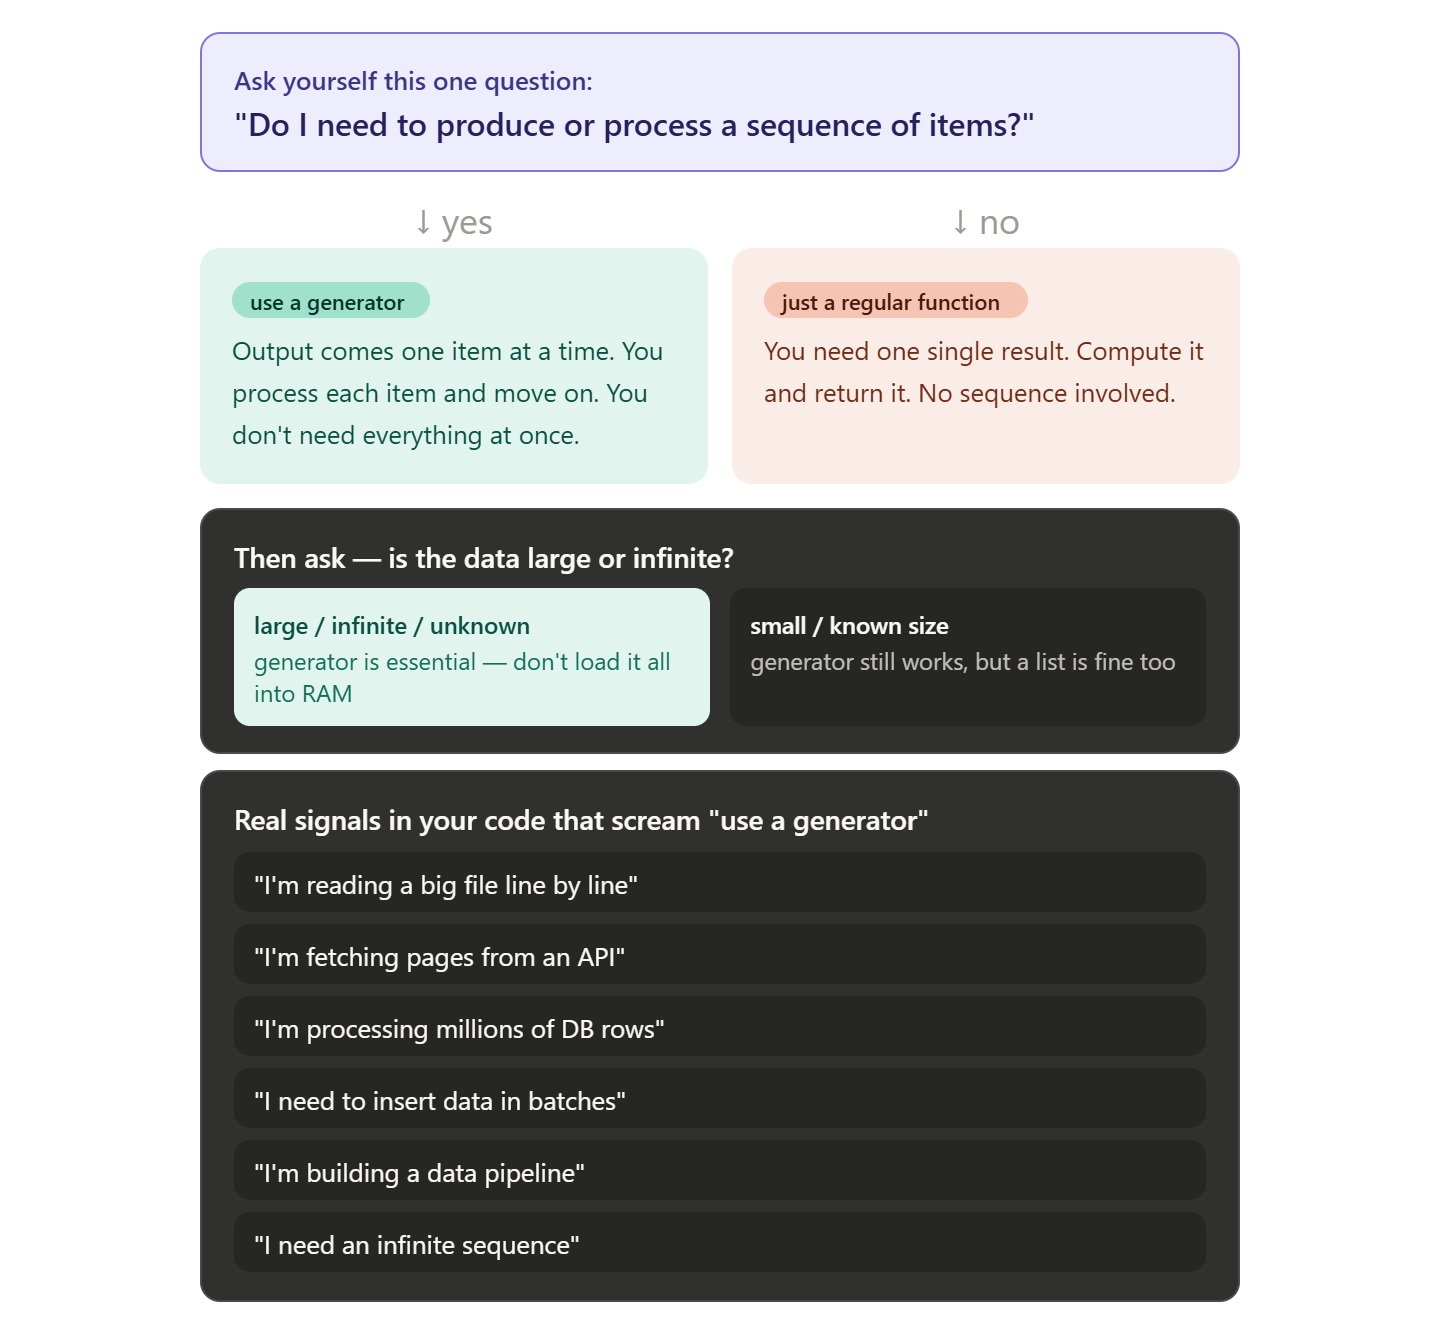